In [2]:
import vertexai 
from vertexai.generative_models import (
    FunctionDeclaration,
    GenerationConfig,
    GenerativeModel,
    Tool,
    HarmCategory,
    HarmBlockThreshold) 
import json
from tqdm import tqdm
import jsonlines
import math 
import pandas as pd 
import numpy as np 

from sklearn import metrics 

In [3]:
PROJECT_ID = "proj-sales-recommender-dev"
LOCATION = "us-central1" 
BUCKET = "sales_recommender_dev_bucket"
DATASET_NAME = f"gs://{BUCKET}/data/cc_classification_sample.csv"

vertexai.init(project=PROJECT_ID, location=LOCATION)

In [7]:
MODEL_ID = "gemini-2.0-flash-001"

model = GenerativeModel(
    MODEL_ID,
    safety_settings={
            HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
            HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
            HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
            HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_NONE,
        },
)

### Add LatLong and Nearest Branch

In [8]:
def haversine_distance_miles_numpy(lat1, lon1, lat2_array, lon2_array):
    """
    Calculates the haversine distance between a single point (lat1, lon1)
    and an array of points (lat2_array, lon2_array) using NumPy for efficiency.

    Args:
        lat1 (float): Latitude of the single point.
        lon1 (float): Longitude of the single point.
        lat2_array (numpy.ndarray): Array of latitudes for the other points.
        lon2_array (numpy.ndarray): Array of longitudes for the other points.

    Returns:
        numpy.ndarray: Array of distances in miles.
    """
    R_miles = 6371.0 * 0.621371  # Earth's radius in miles

    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = np.radians(lat2_array)
    lon2_rad = np.radians(lon2_array)

    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2) ** 2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distances = R_miles * c
    return distances

def find_nearby_branch_haversine(row, df_branch, radius_miles=60, max_branches=5):
    """
    Find all branches within specified radius for each location in df_bq using haversine distance

    Args:
        df_bq: DataFrame with customer/location data
        df_branch: DataFrame with branch locations
        radius_miles: Search radius in miles
        max_branches: Maximum number of nearby branches to return

    Returns:
        pd.Series containing dictionaries of nearby warehouses and their distances
    """
    # Convert warehouse coordinates to numpy arrays for vectorized calculation
    branch_lats = df_branch["Latitude"].values
    branch_longs = df_branch["Longitude"].values

    distances = haversine_distance_miles_numpy(
        row["Latitude"], row["Longitude"], branch_lats, branch_longs
    )
    df_branch["distance"] = distances.round(2)
    nearby_pairs = df_branch[df_branch["distance"] <= radius_miles].sort_values(
        "distance"
    ).head(max_branches)
    nearby_pairs = nearby_pairs[
        ["BranchNumber", "distance", "Longitude", "Latitude", "City2", "StProv"]
    ].to_dict(orient="records")

    # Return np.nan if no nearby branches are found
    if not nearby_pairs:
        return np.nan

    return nearby_pairs


In [9]:
# Read the Excel file
file_path = 'data/branch_lat_long.xlsx'
xls = pd.ExcelFile(file_path)

distance_df = pd.read_excel(xls, sheet_name='Sheet1')

# Split LatLon column into separate latitude and longitude columns
distance_df[['Latitude', 'Longitude']] = distance_df['LatLon'].str.split(',', expand=True)

# Convert string values to float
distance_df['Latitude'] = distance_df['Latitude'].astype(float)
distance_df['Longitude'] = distance_df['Longitude'].astype(float)
distance_df = distance_df.drop_duplicates(subset=['BranchNumber', 'LatLon'])

In [10]:
# Extract coordinates from project address string 
def extract_lat_long(address): 
    address = address.replace("'", '"').replace("None","null").replace("Decimal(", "").replace(")", "")
    json_address = json.loads(address)
    lat = json_address[0]['ns0:Latitude']
    long = json_address[0]['ns0:Longitude']
    return lat, long

# Fetch representative branch from list of closest branches
def extract_branch_location(row, branch_selection = "min"): 
    distances = []
    if row['branches'] is np.nan:
        return None
    for branch in row['branches']:
        distances.append(branch['distance'])
    if branch_selection == "min": 
        return min(distances) 
    elif branch_selection == "avg":
        return sum(distances)/len(distances)

In [4]:
df = pd.read_csv(DATASET_NAME)
labeled_df = df.rename(columns={'Search Name': 'Product', 'FBM Relevance': 'True Relevance'})
relevant_columns = ['Product', 'True Relevance', 'ProjectID', 'Title',  'Query', 
                    'Stage','Valuation_Value',
                    'Valuation_Currency', 'Parameters_Parameter_Ownership',
                    'Parameters_Parameter_WorkType', 'Parameters_Parameter_Structures',
                    'DocumentAvailability_Plans', 'DocumentAvailability_Specs',
                    'DocumentAvailability_Addenda', 'ParentCategories_PrimaryCategoryName',
                    'ParentCategories_ParentCategory', 'Addresses_Address',
                    'Details_Detail_Scope', 'Details_Detail_Notes', 'Details_Detail',
                    'RSMeansMaterialDivisions_Division_Metals',
                    'RSMeansMaterialDivisions_Division_ThermalandMoistureProtection',
                    'RSMeansMaterialDivisions_Division_Openings',
                    'RSMeansMaterialDivisions_Division_Finishes',
                    'RSMeansMaterialDivisions_Division_Masonry', 'Details_Detail_Details',
                    'Materials_Material', 'Notes_Note'] 
labeled_df = labeled_df[relevant_columns]
labeled_df.dropna(subset = ['Product', 'True Relevance'], inplace=True)

In [8]:
labeled_df['True Relevance'].value_counts()/labeled_df.shape[0] * 100

True Relevance
High            50.000000
Very High       32.666667
Moderate        10.666667
Low              5.333333
Not Relevant     1.333333
Name: count, dtype: float64

In [12]:
# Extract latitude and longitude from Addresses_Address
labeled_df['LatLong'] = labeled_df['Addresses_Address'].apply(lambda x: extract_lat_long(x))
for _, row in labeled_df.iterrows():
    lat, long = row['LatLong']
    labeled_df.at[_, 'Latitude'] = float(lat)
    labeled_df.at[_, 'Longitude'] = float(long)

# Find nearby branches for each location
labeled_df['branches'] = labeled_df.apply(lambda row: find_nearby_branch_haversine(row, distance_df), axis=1)
labeled_df['closest_branch'] = labeled_df.apply(lambda row: extract_branch_location(row), axis=1)
labeled_df.drop(columns=['LatLong', 'branches'], inplace=True)

## Prompt Comparison

In [13]:
unlabeled_df = labeled_df.drop('True Relevance', axis=1)

In [ ]:
boolean_filters = pd.read_csv(f"gs://{BUCKET}/data/boolean_filters_latest.csv")
boolean_filters = json.loads(boolean_filters.to_json(orient='records'))

In [15]:
def prompt_v1(cc_project_json, search_terms):
    question = f'''

    **Objective:** Classify ConstructConnect projects as very high, high, moderate, low, very low, or not relevant.

        **Instructions:**

        1. **Analyze the provided JSON data:** Understand the project details, including relevant fields and data points.  The JSON data representing ConstructConnect project is provided in **Project Data**.

        2. **Utilize Search terms** to identify relevant products, materials, and phrases. The search terms are privided in the **Search Terms** section.

        3. **Classify Projects:**
            * Prioritize projects based on how relevant the inputs are to the search terms.
            * When other factors are equal, prioritize higher-value projects (e.g., higher total dollar amount).

        4. **Estimate Relevancy:** Estimate the relevancy of each project based on the matching materials in the "Relevant Materials" list and total dollar amount.

        5. **Respond in valid JSON:** Return ONLY the JSON response, as shown in the example below. The JSON should contain the classification of the project as very high, high, moderate, low, or not relevant along with the reasoning as shown in the example below.

        **Input Data:**

        **Project Data:**
        {cc_project_json}
    
        **Search Terms:**
        {search_terms}

        **Example Output:**
        [
        {{"ProjectID": 1006193703, "Relevance": "Very High", "Reasoning": "Project mentions 'steel beams' and 'concrete mix,' matching our key products in the 'Structural Steel' and 'Concrete' categories. The project is in the 'Post Bid' stage, located in Illinois, and has a high value."}},
        {{"ProjectID": 1006193706, "Relevance": "Moderate", "Reasoning": "Project mentions 'roofing materials,' which is relevant to our 'Roofing' category. The project is in the 'Biddate Set' stage, location unknown (assumed outside Illinois), and value unknown (assumed low)."}},
        {{"ProjectID": 1837563703, "Relevance": "Not Relevant", "Reasoning": "No relevant products mentioned. Project is in the 'Planning' stage and located outside Illinois."}}
        ]
        '''
    prompt = question
    contents = [prompt]

    # Generate text using non-streaming method
    response = model.generate_content(contents)
    return response.text


In [119]:
def prompt_v2(cc_project_json, search_terms):
    question = f'''
        <prompt>
        <objective>Classify ConstructConnect projects as very high, high, moderate, low, very low, or not relevant.</objective>
        <instructions>
            <step>
                <description>Analyze the provided JSON data:</description>
                <details>Understand the project details, including relevant fields and data points. The JSON data representing ConstructConnect projects is provided as "Project Data".</details>
            </step>
            <step>
                <description>Utilize Search Terms:</description>
                <details>identify relevant products, materials, and phrases. The search terms are privided in the **Search Terms** section.</details>
               </step>
            <step>
                <description>Classify Projects:</description>
                <details>
                    <point>Prioritize projects based on how relevant the inputs are to the search terms.</point>
                    <point>When other factors are equal, prioritize higher-value projects (e.g., higher total dollar amount).</point>
                </details>
            </step>
            <step> 
                <description>Estimate Relevancy:</description>
                <details>Estimate the relevancy of each project based on the matching materials and total dollar amount.</details>
            <step>
                <description>Respond in JSON:</description>
                <details>Return ONLY the JSON response, as shown in the example below. The JSON should be a list of project evaluations, classifying each project as "very high," "high," "moderate," "low," "very low," or "not relevant." Include the reasoning behind each classification.</details>
            </step>
        </instructions>
        <input_data>
            <project_data>
                <description>Project Data</description>
                <value>{cc_project_json}</value>
            </project_data>
            <search_terms>
                <description>Search Terms</description>
                <value>{search_terms}</value>
        </input_data>
        <example_output>
            <json_example>
                {{"ProjectID": 1006193703, "Relevance": "Very High", "Reasoning": "Project mentions 'steel beams' and 'concrete mix,' matching our key products in the 'Structural Steel' and 'Concrete' categories. The project is in the 'Post Bid' stage, located in Illinois, and has a high value."}}
            </json_example>
        </example_output>
        </prompt>
    
        '''
    prompt = question
    contents = [prompt]

    # Generate text using non-streaming method
    response = model.generate_content(contents)
    return response.text


In [ ]:
def prompt_v3(cc_project_json, search_terms, product):
    question = f'''

    **Objective:** Classify ConstructConnect projects as very high, high, moderate, low, very low, or not relevant.

        **Instructions:**

        1. **Analyze the provided JSON data:** Understand the project details, including relevant fields and data points. The JSON data representing ConstructConnect project is provided in **Project Data**.

        2. **Utilize Search terms** to identify relevant products, materials, and phrases. The search terms are privided in the **Search Terms** section.

        3. **Consider Project Details**: Understand project specifications. Consider visibility, opportunity for long-term work, and amount of interior construction and specialized work. 

        4. **Classify Projects:**
            * Prioritize projects based on how relevant the inputs are to the search terms.
            # Prioritize projects based on project details, as specified in the previous step.
            * When other factors are equal, prioritize higher-value projects (e.g., higher total dollar amount).

        5. **Estimate Relevancy:** Estimate the relevancy of each project based on the matching materials and total dollar amount.

        6. **Respond in valid JSON:** Return ONLY the JSON response, as shown in the example below. The JSON should contain the classification of the project as very high, high, moderate, low, or not relevant along with the reasoning as shown in the example below.

        **Input Data:**

        **Product:** 
        {product}

        **Project Data:**
        {cc_project_json}
    
        **Search Terms:**
        {search_terms}

        **Example Output:**
        [
          {{"ProjectID": 1837563703, "Relevance": "Not Relevant", "Reasoning": "No relevant products mentioned. Project is in the 'Planning' stage and located outside Illinois."}}
          {{"ProjectID": 1837563704, "Relevance": "Low", "Reasoning": "Project has some relevant categories in the search. The project will require little interior work and is a one-time job."}}
          {{"ProjectID": 1006193701, "Relevance": "Moderate", "Reasoning": "Project mentions 'steel beams' and 'concrete mix,' matching our key products in the 'Structural Steel' and 'Concrete' categories. The project has moderate valuation."}}
          {{"ProjectID": 1837563705, "Relevance": "High", "Reasoning": "Project mentions 'steel beams', matching our products in the 'Structural Steel' categories. The project has some dollar valuation and will require higher specs and specialized work."}}
          {{"ProjectID": 1006193702, "Relevance": "Very High", "Reasoning": "Project mentions 'roofing materials,' which is relevant to our 'Roofing' category. The project is commercial, has high visibility, and opportunity for specialized work."}}
        ]
        '''
    prompt = question
    contents = [prompt]

    # Generate text using non-streaming method
    response = model.generate_content(contents)
    return response.text


In [181]:
def prompt_v4(cc_project_json, search_terms, product):
  question = f'''
  <prompt>
    <objective>Classify ConstructConnect projects as very high, high, moderate, low and not relevant.</objective>
    <instructions>
      <step>
        <description>Analyze Project Data:</description>
        <details>
          <point>Parse the provided JSON data representing ConstructConnect projects.</point>
          <point>Understand the project details, including relevant fields and data points. The JSON data representing ConstructConnect projects is provided as "Project Data".</point>
        </details>
      </step>
      <step>
        <description>Utilize Search Terms:</description>
          <details>
            <point>Identify relevant products, materials, and phrases. The search terms are provided in the "Search Terms" section.</point>
      </step>
      <step>
        <description>Consider Project Type:</description>
        <details>
          <point> Understand project specifications. Consider visibility, opportunity for long-term work, and amount of interior construction and specialized work. 
        </details>
      </step>
      <step>
        <description>Classify Projects:</description>
        <details>
          <point>Classify each project as "very high", "high", "moderate", "low" and "not relevant".</point>
          <point>Highly prioritize projects based on how relevant the inputs are to the search terms.</point>
          <point>Prioritize projects based on project details, as specified in the previous step..</point>
          <point>When other factors are equal, prioritize higher-value projects (e.g., higher total dollar amount).</point>
          <point>Assign the final classification to the project.</point>
        </details>
      </step>
      <step>
        <description>Respond in JSON:</description>
        <details>Return ONLY the JSON response, as shown in the examples below. The JSON should be a list of project evaluations, classifying each project as "very high," "high," "moderate," "low," "very low," or "not relevant." Include the reasoning behind each classification.</details>
      </step>
    </instructions>
    <input_data>
      <product>
          <description>Product</description>
          <value>{product}</value>
      </product>
      <project_data>
          <description>Project Data</description>
          <value>{cc_project_json}</value>
      </project_data>
      <search_terms>
          <description>Search Terms</description>
          <value>{search_terms}</value>
      </search_terms>
    </input_data>
    <example_outputs>
        <json_example>
          {{"ProjectID": 1837563703, "Relevance": "Not Relevant", "Reasoning": "No relevant products mentioned. Project is in the 'Planning' stage and located outside Illinois."}}
        </json_example>
        <json_example>
          {{"ProjectID": 1837563704, "Relevance": "Low", "Reasoning": "Project has some relevant categories in the search. The project will require little interior work and is a one-time job."}}
        </json_example>
        <json_example>
            {{"ProjectID": 1006193701, "Relevance": "Moderate", "Reasoning": "Project mentions 'steel beams' and 'concrete mix,' matching our key products in the 'Structural Steel' and 'Concrete' categories. The project has moderate valuation."}}
        </json_example>
        <json_example>
          {{"ProjectID": 1837563705, "Relevance": "High", "Reasoning": "Project mentions 'steel beams', matching our products in the 'Structural Steel' categories. The project has some dollar valuation and will require higher specs and specialized work."}}
        </json_example>
        <json_example>
          {{"ProjectID": 1006193702, "Relevance": "Very High", "Reasoning": "Project mentions 'roofing materials,' which is relevant to our 'Roofing' category. The project is commercial, has high visibility, and opportunity for specialized work."}}
        </json_example>
    </example_outputs>
</prompt>
'''
  prompt = question
  contents = [prompt]

  # Generate text using non-streaming method
  response = model.generate_content(contents)
  return response.text

  

In [1]:
def prompt_v5(cc_project_json, search_terms, search):
    question = f'''

    **Objective:** Classify ConstructConnect projects as very high, high, moderate, low, very low, or not relevant.

        **Instructions:**

        1. **Analyze the provided JSON data:** Understand the project details, including relevant fields and data points. The JSON data representing ConstructConnect project is provided in **Project Data**.

        2. **Utilize Search Terms:** Identify relevant products, materials, and phrases. The search terms are provided in the **Search Terms** section.

        3. **Consider Project Types:** Identify project type. Determine if the project is specialized and has high opportunity for work and visibility. 
        Examples of specialized projects are: 
            * Hospital and health services
            * Churches
            * Commercial real estate
            * Large residential apartments/dormitories
            * University/College buildings
            * Auditoriums
            * Senior living homes
        Examples of non-specialized projects with very low priority are:
            * One-time projects
            * Small residential projects
            * Golf courses

        4. **Identify Building Type**: Identify building type, including interior complexity and specialized work. 

        5. **Identify Locations and Distance:** Identify the project location and distance from nearest branch. Consider if a branch is too far away from a location. 
        Urban areas should have closer branches, while rural areas can have branches further away.

        6. **Identify Associated Brands:** Identify associated brands to the product. Associated brands include: 
            * Armstrong Ceilings 
            * Sto 
            * Dryvit

        7. **Identify Available Plans:** Identify if the project has detailed and available plans and specs.

        8. **Classify Projects:**
            a. Prioritize projects based on how relevant the inputs are to the search terms.
            b. Next, prioritize projects based on the project type, as specified in the previous steps. Deprioritize non-specialized projects. 
            c. Next, prioritize building types based on how complex the interior work is, as specified in the previous steps. Deprioritize projects with little interior work.
            d. Next, prioritize projects that have reasonable distance to the nearest branch, as specified in the previous steps. Deprioritize projects that are too far away from a branch.
            e. Next, prioritize projects that have associated brands, as specified in the previous steps. Lack of associated brands will not lower the priority.
            f. Next, increase priority if the project has detailed plans and specs. Lack of plans and specs will not lower the priority. 
            g. When other factors are equal, prioritize higher-value projects (e.g., higher total dollar amount).

        8. **Estimate Relevancy:** Estimate the relevancy of each project based on the above factors and total dollar amount.

        9. **Respond in valid JSON:** Return ONLY the JSON response, as shown in the example below. The JSON should contain the classification of the project as very high, high, moderate, low, or not relevant along with the reasoning as shown in the example below.

        **Input Data:**

        **Search:** 
        {search}

        **Project Data:**
        {cc_project_json}
    
        **Search Terms:**
        {search_terms}

        **Example Output:**
        [
          {{"ProjectID": 1837563703, "Relevance": "Not Relevant", "Reasoning": "The project details and materials do not contain any mention of the search terms. Therefore, it is not relevant."}} 
          {{"ProjectID": 1837563704, "Relevance": "Low", "Reasoning": "Project has some search terms in the description such as "steel". The project will require little interior work and is a one-time job."}}
          {{"ProjectID": 1006193701, "Relevance": "Moderate", "Reasoning": "Project mentions 'steel beams' and 'concrete mix,' matching our search terms "STEEL" and "CONCRETE". The project has moderate valuation."}}
          {{"ProjectID": 1837563705, "Relevance": "High", "Reasoning": "Project mentions 'steel beams," "concrete," and "gysum," matching many of the provided search terms. The project has high dollar valuation and will require higher specs. "}}
          {{"ProjectID": 1006193702, "Relevance": "Very High", "Reasoning": "Project mentions 'roofing materials", "concrete", "fry", and "steel", matching our search terms. The project is commercial, has high visibility, and opportunity for specialized work."}}
        ]
        '''
    prompt = question
    contents = [prompt]


    # Generate text using non-streaming method
    response = model.generate_content(contents)
    return response.text


In [16]:
def process_and_save_prompt_output(prompt_function, df, boolean_filters, output_filename): 

    responses = []
    for _, row in tqdm(df.iterrows(), total = len(df)):

        # Find matching search terms
        product = row['Product']
        row = row.drop('Product')
        search_terms = [filter['Query'] for filter in boolean_filters if filter['Filter'] == product][0]

        # Convert row to JSON
        row_json_str = row.to_json()
        cc_project_json_record = json.loads(row_json_str)

        # Fetch relevancy from LLM 
        llm_output = prompt_function(cc_project_json_record, search_terms, product)
        llm_output = llm_output.replace("```json", "").replace("```", "").strip()

        try: 
            json_output = json.loads(llm_output)
            responses.append(json_output)
        except json.JSONDecodeError as e: 
            print(f"Error decoding JSON: {e}")
            print(f"Problematic string: {llm_output}")
            continue
            
    with jsonlines.open(output_filename, 'w') as writer:
        writer.write_all(responses)

In [13]:
# convert jsonl file to dataframe
def jsonl_to_df(filepath): 

    with open(filepath, 'r') as f:
        lines = f.readlines()

    data = [] 
    for line in lines: 
        json_data = json.loads(line)[0]
        project_id = json_data['ProjectID']
        relevance = json_data['Relevance']
        reasoning = json_data['Reasoning']
        data.append([project_id, relevance, reasoning])
        
    df = pd.DataFrame(data, columns=['ProjectID', 'Relevance', 'Reasoning'])
    return df

In [44]:
# process_and_save_prompt_output(prompt_v1, unlabeled_df, boolean_filters, 'predictions/v1_bullet.jsonl')

In [45]:
# process_and_save_prompt_output(prompt_v2, unlabeled_df, boolean_filters, 'predictions/v2_xml.jsonl')

In [46]:
# process_and_save_prompt_output(prompt_v3, unlabeled_df, boolean_filters, 'predictions/v3_bullet_feedback.jsonl')

In [47]:
# process_and_save_prompt_output(prompt_v4, unlabeled_df, boolean_filters, 'predictions/v4_xml_feedback.jsonl')

In [18]:
process_and_save_prompt_output(prompt_v5, unlabeled_df, boolean_filters, 'predictions/v5_bullet_feedback_priority.jsonl')

 47%|████▋     | 71/150 [01:28<01:41,  1.28s/it]

Error decoding JSON: Expecting ',' delimiter: line 5 column 176 (char 235)
Problematic string: [
  {
    "ProjectID": 1002491235,
    "Relevance": "High",
    "Reasoning": "The project is an office building, which is a commercial project type, increasing its relevance. It is currently under construction. The search terms match "armstrong", "ceilings", and "acoustic ceilings". The project is reasonably close to a branch at 13.76 miles. RSMeans Material Divisions includes Acoustical Ceilings, Acoustical Ceiling Suspension Assemblies, and Gypsum Board. Valuation is high at $7,000,000. The project is likely to have a significant ceiling component given the mention of acoustical ceilings and suspension assemblies, making it a high-relevance opportunity."
  }
]


100%|██████████| 150/150 [03:08<00:00,  1.26s/it]


## Prompt Evaluation

In [14]:
# Read results
responses_df = labeled_df.copy()  
version_responses = ['v1_bullet', 'v2_xml', 'v3_bullet_feedback', 'v4_xml_feedback', 'v5_bullet_feedback_priority']

# Load df versions 
for version in version_responses:
    version_df = jsonl_to_df(f'predictions/{version}.jsonl')
    version_df.rename({'Relevance': f'Relevance_{version}', 'Reasoning': f'Reasoning_{version}'}, axis=1, inplace=True)
    responses_df = responses_df.merge(version_df, on='ProjectID', how='left')

# Fetch and cast LLM response columns to lowercase 
relevance_columns = responses_df.filter(regex='Relevance').columns
responses_df.dropna(subset=relevance_columns, inplace=True)

for col in relevance_columns: 
    responses_df[col] = responses_df[col].astype(str).str.lower()

FileNotFoundError: [Errno 2] No such file or directory: 'predictions/v1_bullet.jsonl'

In [11]:
from sklearn.preprocessing import OrdinalEncoder 

# Encode the relevance columns
labels = ['not relevant', 'low', 'moderate', 'high', 'very high']
encoder = OrdinalEncoder(categories=[labels])

for col in relevance_columns: 
    responses_df[col] = encoder.fit_transform(responses_df[[col]])

NameError: name 'relevance_columns' is not defined

In [12]:
from sklearn.metrics import f1_score

# Calculate F1 Score for each version
for col in relevance_columns: 
    print(f"F1 Score for {col}: ", f1_score(responses_df['True Relevance'], responses_df[col], average='weighted'))

NameError: name 'relevance_columns' is not defined

In [ ]:
responses_df

In [61]:
v5_responses = responses_df[['ProjectID', 'True Relevance', 'Relevance_v5_bullet_feedback_priority', 'Reasoning_v5_bullet_feedback_priority']]

# Rows where relevance were more than 1 class away 
print(v5_responses[abs(v5_responses['True Relevance'] - v5_responses['Relevance_v5_bullet_feedback_priority']) > 1].to_markdown())

|     |   ProjectID |   True Relevance |   Relevance_v5_bullet_feedback_priority | Reasoning_v5_bullet_feedback_priority                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
|----:|------------:|-----------------:|----------------------------------------:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [9]:
v5_responses['Relevance_v5_bullet_feedback_priority'].value_counts()/150

NameError: name 'v5_responses' is not defined

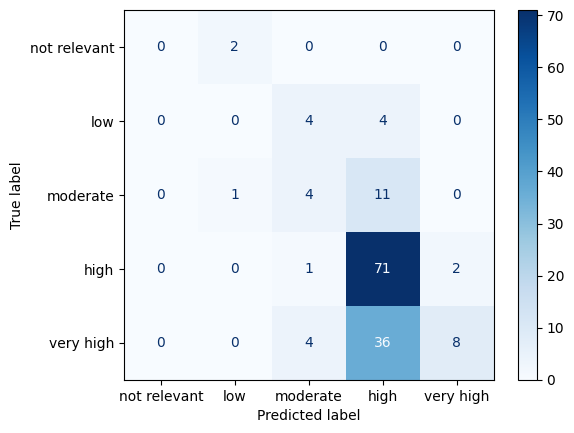

In [ ]:
conf_matrix = metrics.confusion_matrix(responses_df['True Relevance'], responses_df['Relevance_v5_bullet_feedback_priority'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=labels)
cm_display.plot(cmap='Blues')

In [65]:
labeled_df.rename({"True Relevance": "Relevance"}, axis=1, inplace=True)
labeled_df.to_csv('data/labeled_df_relevance.csv', index=False)